In [2]:
def season_ranking_expectation(match, standings):
    """
    Predict match winner based on season-end rankings.

    Args:
        match: Single match row with season, home_team, away_team columns
        standings: DataFrame with season, team_name, rank columns

    Returns:
        +1 for expected home win, -1 for expected away win, 0 if unable to determine
    """
    try:
        season = match.season
        hometeam = match.home_team
        awayteam = match.away_team

        # Get rankings with error handling
        home_rank_data = standings.loc[(standings['season'] == season) & (standings['team_name'] == hometeam), 'rank']
        away_rank_data = standings.loc[(standings['season'] == season) & (standings['team_name'] == awayteam), 'rank']

        # Check if rankings exist
        if home_rank_data.empty or away_rank_data.empty:
            return 0  # Unable to predict

        homestanding = home_rank_data.iloc[0]
        awaystanding = away_rank_data.iloc[0]

        # Handle NaN values
        if pd.isna(homestanding) or pd.isna(awaystanding):
            return 0

        # Lower rank number = better team
        if homestanding < awaystanding:
            return 1  # Home team expected to win
        else:
            return -1  # Away team expected to win

    except Exception as e:
        return 0  # Return neutral if any error occurs

def betting_odds_expectation(match):
    """
    Predict match winner based on betting odds.

    Args:
        match: Single match row with OddHome, OddAway columns

    Returns:
        +1 for expected home win, -1 for expected away win, 0 if unable to determine
    """
    try:
        # Check if odds data exists and is valid
        if pd.isna(match.OddHome) or pd.isna(match.OddAway):
            return 0

        if match.OddHome <= 0 or match.OddAway <= 0:
            return 0

        # Lower odds = higher probability of winning
        if match.OddHome < match.OddAway:
            return 1  # Home team expected to win
        else:
            return -1  # Away team expected to win

    except Exception as e:
        return 0  # Return neutral if any error occurs


# Testing the enhanced functions
import pandas as pd
import numpy as np
from pathlib import Path

base_dir = Path().resolve()
print("Working dir:", base_dir)

standings_path = (base_dir / "../csv/auxiliary/premier_league_standings_all_seasons.csv").resolve()
matches_path = (base_dir / "../csv/processed/premier_league1_std.csv").resolve()
standings = pd.read_csv(standings_path)
match = pd.read_csv(matches_path).iloc[1]

oddwin = betting_odds_expectation(match)
rankwin = season_ranking_expectation(match, standings)
print(f"Ranking prediction: {rankwin}")
print(f"Odds prediction: {oddwin}")
print(f"Actual result: {match.hometeamresult}")


Working dir: /Users/mikeyautorino/Desktop/skillvsluck/data/european_soccer/code
Ranking prediction: -1
Odds prediction: -1
Actual result: -1


In [3]:
def calculate_upset_frequency(matches_df, predictor_function, **predictor_kwargs):
    """
    Core function to calculate upset frequencies using any predictor function.

    Args:
        matches_df: DataFrame with match data including hometeamresult column
        predictor_function: Function that takes a match row and returns +1/-1/0 for prediction
        **predictor_kwargs: Additional keyword arguments to pass to predictor function

    Returns:
        dict with upset statistics including:
        - total_predictions: number of matches where prediction was made
        - total_upsets: number of upsets (draws count as 0.5)
        - upset_frequency: proportion of weighted upsets
        - correct_predictions: number of correct predictions
        - accuracy: prediction accuracy
    """

    predictions = []
    actual_results = []

    for _, match in matches_df.iterrows():
        prediction = predictor_function(match, **predictor_kwargs)
        if prediction != 0:
            predictions.append(int(prediction))
            actual_results.append(int(match.hometeamresult))

    if not predictions:
        return {
            'total_predictions': 0,
            'total_upsets': 0.0,
            'upset_frequency': 0.0,
            'correct_predictions': 0,
            'accuracy': 0.0,
            'non_draw_matches': 0,
            'draw_predictions': 0
        }

    predictions = np.asarray(predictions, dtype=int)
    actual_results = np.asarray(actual_results, dtype=int)

    draws_mask = actual_results == 0
    non_draw_mask = ~draws_mask
    upset_mask = ((predictions == 1) & (actual_results == -1)) | ((predictions == -1) & (actual_results == 1))

    total_upsets = float(upset_mask[non_draw_mask].sum())
    draw_predictions = int(draws_mask.sum())
    total_upsets += 0.5 * draw_predictions

    total_predictions = int(len(predictions))
    correct = int((predictions == actual_results).sum())
    non_draw_matches = int(non_draw_mask.sum())

    return {
        'total_predictions': total_predictions,
        'total_upsets': total_upsets,
        'upset_frequency': total_upsets / total_predictions if total_predictions > 0 else 0.0,
        'correct_predictions': correct,
        'accuracy': correct / total_predictions if total_predictions > 0 else 0.0,
        'non_draw_matches': non_draw_matches,
        'draw_predictions': draw_predictions
    }



In [4]:
def overall_upset_frequency_by_league(league_data_dict, standings_dict, predictor_function, **predictor_kwargs):
    """
    Calculate overall upset frequency for each league.

    Args:
        league_data_dict: Dict of league_name -> matches DataFrame
        standings_dict: Dict of league_name -> standings DataFrame (for ranking predictor)
        predictor_function: Predictor function to use
        **predictor_kwargs: Additional arguments for predictor

    Returns:
        DataFrame with columns: league, upset_frequency, total_predictions, accuracy
    """
    results = []

    for league_name, matches_df in league_data_dict.items():
        if 'standings' in predictor_kwargs:
            kwargs = {**predictor_kwargs, 'standings': standings_dict.get(league_name)}
        else:
            kwargs = predictor_kwargs

        stats = calculate_upset_frequency(matches_df, predictor_function, **kwargs)

        results.append({
            'league': league_name,
            'upset_frequency': stats['upset_frequency'],
            'total_predictions': stats['total_predictions'],
            'total_upsets': stats['total_upsets'],
            'accuracy': stats['accuracy'],
            'non_draw_matches': stats['non_draw_matches'],
            'draw_predictions': stats['draw_predictions']
        })

    return pd.DataFrame(results)



In [5]:
def seasonal_upset_frequency(league_data_dict, standings_dict, predictor_function, **predictor_kwargs):
    """
    Calculate upset frequency by season and league.

    Args:
        league_data_dict: Dict of league_name -> matches DataFrame
        standings_dict: Dict of league_name -> standings DataFrame (for ranking predictor)
        predictor_function: Predictor function to use
        **predictor_kwargs: Additional arguments for predictor

    Returns:
        DataFrame with columns: league, season, upset_frequency, total_predictions, accuracy
    """
    results = []

    for league_name, matches_df in league_data_dict.items():
        seasons = sorted(matches_df['season'].unique())

        for season in seasons:
            season_matches = matches_df[matches_df['season'] == season]

            if 'standings' in predictor_kwargs:
                kwargs = {**predictor_kwargs, 'standings': standings_dict.get(league_name)}
            else:
                kwargs = predictor_kwargs

            stats = calculate_upset_frequency(season_matches, predictor_function, **kwargs)

            results.append({
                'league': league_name,
                'season': season,
                'upset_frequency': stats['upset_frequency'],
                'total_predictions': stats['total_predictions'],
                'total_upsets': stats['total_upsets'],
                'accuracy': stats['accuracy'],
                'non_draw_matches': stats['non_draw_matches'],
                'draw_predictions': stats['draw_predictions']
            })

    return pd.DataFrame(results)



In [6]:
def team_upset_frequency(league_data_dict, standings_dict, predictor_function, **predictor_kwargs):
    """
    Calculate upset frequency for each team across all seasons.

    Args:
        league_data_dict: Dict of league_name -> matches DataFrame
        standings_dict: Dict of league_name -> standings DataFrame (for ranking predictor)
        predictor_function: Predictor function to use
        **predictor_kwargs: Additional arguments for predictor

    Returns:
        DataFrame with columns: league, team, upset_frequency_home, upset_frequency_away, total_upsets, total_predictions, accuracy
    """
    results = []

    for league_name, matches_df in league_data_dict.items():
        home_teams = set(matches_df['home_team'].unique())
        away_teams = set(matches_df['away_team'].unique())
        all_teams = home_teams.union(away_teams)

        for team in all_teams:
            home_matches = matches_df[matches_df['home_team'] == team].copy()
            away_matches = matches_df[matches_df['away_team'] == team].copy()

            if 'standings' in predictor_kwargs:
                kwargs = {**predictor_kwargs, 'standings': standings_dict.get(league_name)}
            else:
                kwargs = predictor_kwargs

            home_stats = calculate_upset_frequency(home_matches, predictor_function, **kwargs)
            away_stats = calculate_upset_frequency(away_matches, predictor_function, **kwargs)
            overall_stats = calculate_upset_frequency(pd.concat([home_matches, away_matches]), predictor_function, **kwargs)

            results.append({
                'league': league_name,
                'team': team,
                'upset_frequency_home': home_stats['upset_frequency'],
                'upset_frequency_away': away_stats['upset_frequency'],
                'upset_frequency_overall': overall_stats['upset_frequency'],
                'total_upsets_home': home_stats['total_upsets'],
                'total_upsets_away': away_stats['total_upsets'],
                'total_upsets': overall_stats['total_upsets'],
                'total_predictions_home': home_stats['total_predictions'],
                'total_predictions_away': away_stats['total_predictions'],
                'total_predictions': overall_stats['total_predictions'],
                'accuracy_home': home_stats['accuracy'],
                'accuracy_away': away_stats['accuracy'],
                'accuracy_overall': overall_stats['accuracy'],
                'draw_predictions_home': home_stats['draw_predictions'],
                'draw_predictions_away': away_stats['draw_predictions'],
                'draw_predictions': overall_stats['draw_predictions']
            })

    return pd.DataFrame(results)



In [7]:
def load_all_league_data():
    """
    Load match data and standings for all available leagues.
    
    Returns:
        tuple: (league_data_dict, standings_dict) where each is a dict of league_name -> DataFrame
    """
    base_dir = Path().resolve()
    
    # Define league configurations
    leagues = {
        'Premier League': {
            'matches_file': 'premier_league1_std.csv',
            'standings_file': 'premier_league_standings_all_seasons.csv'
        },
        'Serie A': {
            'matches_file': 'serie_a_std.csv',
            'standings_file': 'serie_a_standings_all_seasons.csv'
        },
        'Bundesliga': {
            'matches_file': 'bundesliga_std.csv',
            'standings_file': 'bundesliga_standings_all_seasons.csv'
        },
        'La Liga': {
            'matches_file': 'la_liga_std.csv',
            'standings_file': 'la_liga_standings_all_seasons.csv'
        }
    }
    
    league_data = {}
    standings_data = {}
    
    print("Loading league data...")   
    for league_name, config in leagues.items():
        # Load match data
        matches_path = base_dir / "../csv/processed" / config['matches_file']
        if matches_path.exists():
            matches_df = pd.read_csv(matches_path)
            matches_df['date'] = pd.to_datetime(matches_df['date'])
            league_data[league_name] = matches_df
            print(f"✓ Loaded {league_name} matches: {len(matches_df):,} matches")
        else:
            print(f"✗ Warning: {matches_path} not found")
            
        # Load standings data
        standings_path = base_dir / "../csv/auxiliary" / config['standings_file']
        if standings_path.exists():
            standings_df = pd.read_csv(standings_path)
            standings_data[league_name] = standings_df
            print(f"✓ Loaded {league_name} standings: {len(standings_df):,} team-seasons")
        else:
            print(f"✗ Warning: {standings_path} not found")
    
    print(f"\nSuccessfully loaded {len(league_data)} leagues")
    return league_data, standings_data


In [8]:
# Test the upset frequency functions
print("=" * 60)
print("TESTING UPSET FREQUENCY FUNCTIONS")
print("=" * 60)

league_data, standings_data = load_all_league_data()

print("" + "=" * 60)
print("1. OVERALL UPSET FREQUENCY BY LEAGUE")
print("=" * 60)

print("Using Season Ranking Predictor:")
ranking_results = overall_upset_frequency_by_league(
    league_data, standings_data, season_ranking_expectation, standings=None
)
print(ranking_results[['league', 'upset_frequency', 'accuracy', 'total_predictions', 'draw_predictions']].round(3))

print("Using Betting Odds Predictor:")
odds_results = overall_upset_frequency_by_league(
    league_data, standings_data, betting_odds_expectation
)
print(odds_results[['league', 'upset_frequency', 'accuracy', 'total_predictions', 'draw_predictions']].round(3))



TESTING UPSET FREQUENCY FUNCTIONS
Loading league data...
✓ Loaded Premier League matches: 8,360 matches
✓ Loaded Premier League standings: 440 team-seasons
✓ Loaded Serie A matches: 8,518 matches
✓ Loaded Serie A standings: 454 team-seasons
✓ Loaded Bundesliga matches: 6,426 matches
✓ Loaded Bundesliga standings: 378 team-seasons
✓ Loaded La Liga matches: 8,740 matches
✓ Loaded La Liga standings: 460 team-seasons

Successfully loaded 4 leagues
1. OVERALL UPSET FREQUENCY BY LEAGUE
Using Season Ranking Predictor:
           league  upset_frequency  accuracy  total_predictions  \
0  Premier League            0.328     0.551               8360   
1         Serie A            0.330     0.536               8518   
2      Bundesliga            0.345     0.531               6426   
3         La Liga            0.347     0.527               8740   

   draw_predictions  
0              2028  
1              2278  
2              1601  
3              2199  
Using Betting Odds Predictor:
       

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

all_seasonal_betting = []
all_seasonal_ranking = []
all_team_betting = []
all_team_ranking = []

for league in league_data:
    league_matches = {league: league_data[league]}
    league_standings = {league: standings_data[league]}

    seasonal_betting = seasonal_upset_frequency(
        league_matches, league_standings, betting_odds_expectation
    )
    seasonal_ranking = seasonal_upset_frequency(
        league_matches, league_standings, season_ranking_expectation, standings=league_standings
    )

    team_betting = team_upset_frequency(
        league_matches, league_standings, betting_odds_expectation
    )
    team_ranking = team_upset_frequency(
        league_matches, league_standings, season_ranking_expectation, standings=league_standings
    )

    all_seasonal_betting.append(seasonal_betting)
    all_seasonal_ranking.append(seasonal_ranking)
    all_team_betting.append(team_betting)
    all_team_ranking.append(team_ranking)

combined_seasonal_betting = pd.concat(all_seasonal_betting, ignore_index=True)
combined_seasonal_ranking = pd.concat(all_seasonal_ranking, ignore_index=True)
combined_team_betting = pd.concat(all_team_betting, ignore_index=True)
combined_team_ranking = pd.concat(all_team_ranking, ignore_index=True)

points_std_records = []
for league, standings_df in standings_data.items():
    standings_copy = standings_df.copy()
    standings_copy['season'] = standings_copy['season'].astype(int)
    league_std = (
        standings_copy.groupby('season')['points']
        .std()
        .reset_index()
        .rename(columns={'points': 'points_std'})
    )
    league_std['league'] = league
    points_std_records.append(league_std)

points_std_df = pd.concat(points_std_records, ignore_index=True)



In [11]:
import matplotlib.ticker as mtick

/var/folders/j5/rfspt6hs2z1_fvgbltx8068h0000gn/T/ipykernel_8387/254180338.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='League')
/var/folders/j5/rfspt6hs2z1_fvgbltx8068h0000gn/T/ipykernel_8387/254180338.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='League')


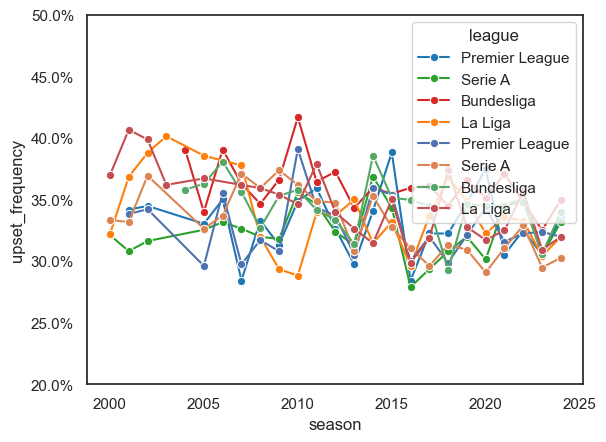

In [29]:
sns.set_theme(style="white")

palette = {
    'Premier League': '#1f77b4',       # blue
    'La Liga': '#ff7f0e',   # orange
    'Serie A': '#2ca02c',   # green
    'Bundesliga': '#d62728' # red
}

ax2 =sns.lineplot(data=combined_seasonal_betting, x='season', y='upset_frequency', hue='league', marker='o', palette=palette)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2.set_ylim(0.2,0.5)
plt.figure(figsize=(12, 6))
plt.xlabel('Season')
plt.ylabel('Upset Frequency')
plt.legend(title='League')
plt.tight_layout()
plt.savefig('soccer_betting_line_upset_freq_draw05.png', dpi=300)
plt.close()

plt.figure(figsize=(10, 6))
ax4 = sns.boxplot(data=combined_seasonal_betting, x='league', y='upset_frequency')
ax4.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax4.set_ylim(0,0.5)
plt.xlabel('League')
plt.ylabel('Upset Frequency')
plt.tight_layout()
plt.savefig('soccer_betting_combined_box_upset_freq_draw05.png', dpi=300)
plt.close()

plt.figure(figsize=(12, 6))
ax1 = sns.lineplot(
    data=combined_seasonal_ranking,
    x='season', y='upset_frequency',
    hue='league', marker='o',
    palette=palette,
    linewidth=2
)
plt.xlabel('Season', fontsize=14)
plt.ylabel('Upset Frequency', fontsize=14)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax1.set_ylim(0.2,0.5)
plt.legend(title='League')
plt.tight_layout()
plt.savefig('standings_combined_line_upset_freq_soccer_draw05.png', dpi=300)
plt.close()


sns.lineplot(data=combined_seasonal_ranking, x='season', y='upset_frequency', hue='league', marker='o')
plt.figure(figsize=(12, 6))
plt.xlabel('Season')
plt.ylabel('Upset Frequency')
plt.legend(title='League')
plt.tight_layout()
plt.savefig('line_upset_freq_soccer.png', dpi=300)
plt.close()

plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=combined_seasonal_ranking, x='league', y='upset_frequency')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_ylim(0,0.5)
plt.ylabel('Upset Frequency (%)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('standings_combined_box_upset_freq_draw05.png', dpi=300)
plt.close()

avg_team_freq_betting = (
    combined_team_betting.groupby(['league'])['upset_frequency_overall']
    .mean()
    .reset_index()
    .sort_values(by='upset_frequency_overall')
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=avg_team_freq_betting,
    x='league',
    y='upset_frequency_overall',
    hue='league',
    dodge=False
)
plt.title('Average Team Upset Frequency by League (Betting Predictor, draw = 0.5)')
plt.xlabel('League')
plt.ylabel('Upset Frequency')
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.savefig('betting_combined_bar_team_upset_freq_draw05.png', dpi=300)
plt.close()

plt.figure(figsize=(12, 6))
sns.lineplot(data=points_std_df, x='season', y='points_std', hue='league', marker='o')
plt.title('Seasonal Points Standard Deviation by League')
plt.xlabel('Season')
plt.ylabel('Points Standard Deviation')
plt.legend(title='League')
plt.tight_layout()
plt.savefig('points_std_line.png', dpi=300)
plt.close()

plt.figure(figsize=(10, 6))
sns.boxplot(data=points_std_df, x='league', y='points_std')
plt.title('Distribution of Season Points Standard Deviations')
plt.xlabel('League')
plt.ylabel('Points Standard Deviation')
plt.tight_layout()
plt.savefig('points_std_box.png', dpi=300)
plt.close()



## Usage Summary

The upset frequency functions now account for draws as 0.5 upsets and support both betting-odds and season-ranking predictors while also computing league-wide season points dispersion.

1. `league_data, standings_data = load_all_league_data()`
2. `overall_upset_frequency_by_league(...)` for betting or ranking predictors (use `standings=None` or pass standings dict).
3. `seasonal_upset_frequency(...)` to track per-season draw-weighted upset rates.
4. `team_upset_frequency(...)` for home/away/overall metrics—including draw counts—for each club.
5. `points_std_df` holds the per-league standard deviation of season points; plots are saved in `output/european_soccer/figures/`.

Draws add 0.5 to `total_upsets`, so `upset_frequency = total_upsets / total_predictions` reflects the new weighting.

## Usage Summary

The upset frequency functions are now complete and ready to use. Here's how to use them:

### 1. Load Data
```python
league_data, standings_data = load_all_league_data()
```

### 2. Calculate Overall Upset Frequencies by League
```python
# Using betting odds predictor
odds_results = overall_upset_frequency_by_league(
    league_data, standings_data, betting_odds_expectation
)

# Using season ranking predictor
ranking_results = overall_upset_frequency_by_league(
    league_data, standings_data, season_ranking_expectation, standings=None
)
```

### 3. Calculate Seasonal Upset Frequencies
```python
seasonal_results = seasonal_upset_frequency(
    league_data, standings_data, betting_odds_expectation
)
```

### 4. Calculate Team Upset Frequencies
```python
team_results = team_upset_frequency(
    league_data, standings_data, betting_odds_expectation
)
```